# Heart Disease Prediction using Artificial Neural Network (ANN)

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_auc_score, roc_curve)

# ✅ Use standalone keras instead of tensorflow.keras
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.random.seed(42)

## 2. Load Dataset

In [6]:
# ---------------------------------------------------------
# Option A – load from your local Excel file (original path)
# df = pd.read_excel(r'C:\Users\shiva\Downloads\HeartDisease.xlsx')
#
# Option B – load from sklearn / UCI (works offline, no file needed)
# ---------------------------------------------------------
from sklearn.datasets import fetch_openml
heart = fetch_openml(name='heart-statlog', version=1, as_frame=True)
df_raw = heart.frame

# Rename to match your original column names
col_map = {
    'age': 'age',
    'sex': 'gender',
    'chest': 'chest_pain',
    'resting_blood_pressure': 'rest_bps',
    'serum_cholestoral': 'cholestrol',
    'fasting_blood_sugar': 'fasting_blood_sugar',
    'resting_electrocardiographic_results': 'rest_ecg',
    'maximum_heart_rate_achieved': 'thalach',
    'exercise_induced_angina': 'exer_angina',
    'oldpeak': 'old_peak',
    'slope': 'slope',
    'number_of_major_vessels': 'ca',
    'thal': 'thalassemia',
    'class': 'target'
}
df = df_raw.rename(columns={k: v for k, v in col_map.items() if k in df_raw.columns})

# Encode categoricals / booleans to numeric
for col in df.columns:
    if df[col].dtype.name in ['category', 'object', 'bool']:
        df[col] = pd.Categorical(df[col]).codes

# Make target binary  (1 = disease, 0 = no disease)
df['target'] = (df['target'] > 0).astype(int)

print(df.shape)
df.head()

(270, 14)


,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


## 3. Exploratory Data Analysis

In [7]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.describe()

Shape: (270, 14)

Missing values:
 age                    0
gender                 0
chest_pain             0
rest_bps               0
cholestrol             0
fasting_blood_sugar    0
rest_ecg               0
thalach                0
exer_angina            0
old_peak               0
slope                  0
ca                     0
thalassemia            0
target                 0
dtype: int64

Data types:
 age                      int64
gender                   int64
chest_pain               int64
rest_bps                 int64
cholestrol               int64
fasting_blood_sugar      int64
rest_ecg                 int64
thalach                  int64
exer_angina              int64
old_peak               float64
slope                    int64
ca                       int64
thalassemia              int64
target                   int64
dtype: object


,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


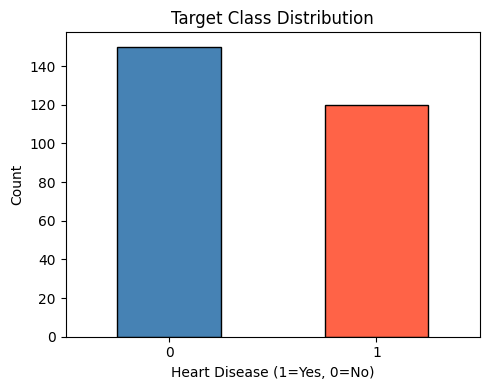

In [8]:
# Target distribution
plt.figure(figsize=(5,4))
df['target'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

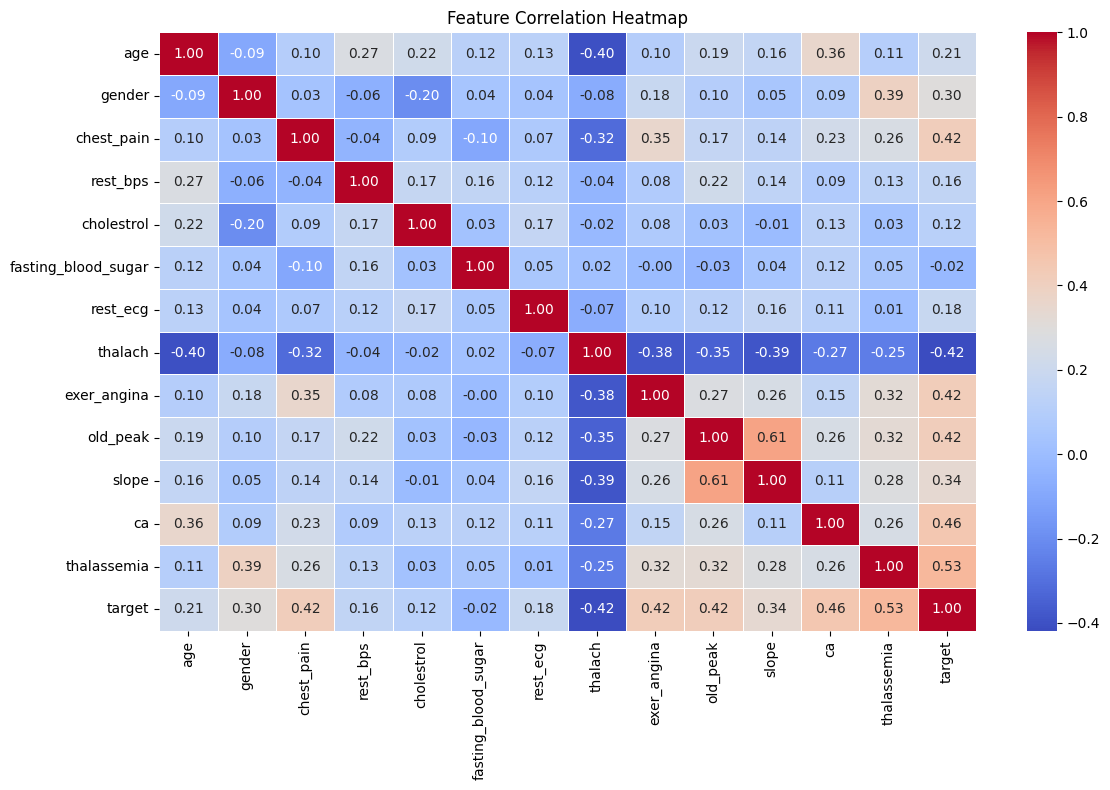

In [9]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]}')
print(f'Test  size : {X_test.shape[0]}')

Train size : 216
Test  size : 54


In [11]:
# Feature scaling – critical for ANN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 5. Build the ANN Model

Architecture:
- **Input layer** : 13 features
- **Hidden layer 1** : 64 neurons, ReLU, BatchNorm, Dropout(0.3)
- **Hidden layer 2** : 32 neurons, ReLU, BatchNorm, Dropout(0.2)
- **Hidden layer 3** : 16 neurons, ReLU
- **Output layer** : 1 neuron, Sigmoid (binary classification)

In [12]:
model = Sequential([
    # Hidden Layer 1
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(16, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Train the Model

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5574 - loss: 0.8113 - val_accuracy: 0.4848 - val_loss: 0.6786
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6284 - loss: 0.6123 - val_accuracy: 0.5455 - val_loss: 0.6427
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7213 - loss: 0.5618 - val_accuracy: 0.6667 - val_loss: 0.6148
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7923 - loss: 0.4758 - val_accuracy: 0.7273 - val_loss: 0.5930
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7486 - loss: 0.4888 - val_accuracy: 0.7879 - val_loss: 0.5740
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8197 - loss: 0.4209 - val_accuracy: 0.7879 - val_loss: 0.5547
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7869 - loss: 0.4408 - val_accuracy: 0.7879 - val_loss: 0.5335
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8470 - loss: 0.3867 - val_accuracy: 0.

## 7. Training History

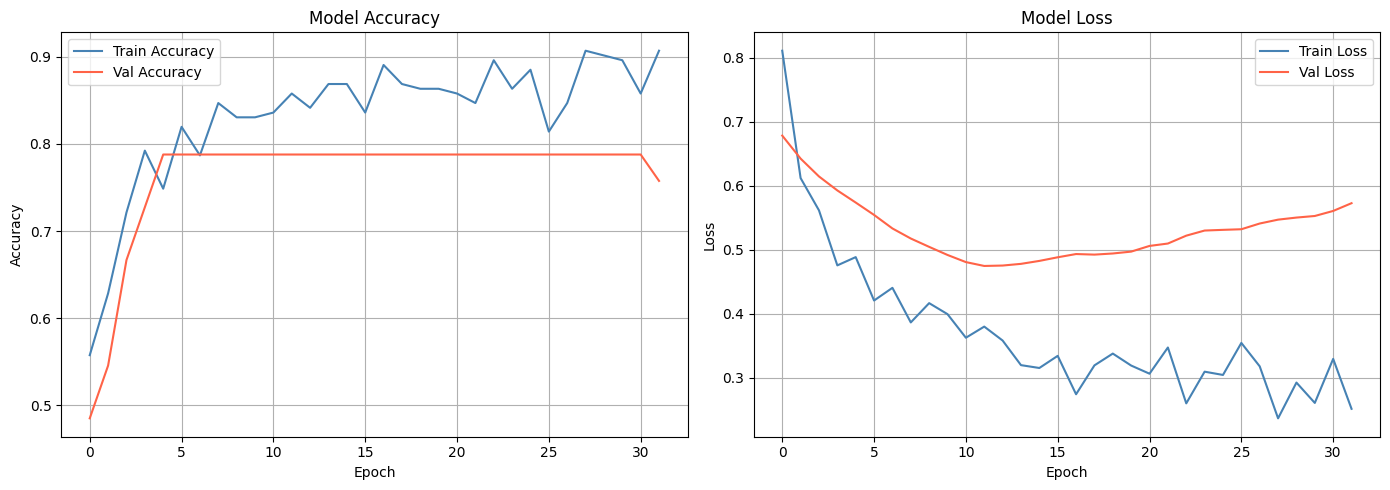

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Model Evaluation

In [15]:
y_pred_prob = model.predict(X_test_sc).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {acc:.4f}')
print(f'ROC-AUC Score : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                            target_names=['No Disease', 'Disease']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Test Accuracy : 0.8333
ROC-AUC Score : 0.9083

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.80      0.84        30
     Disease       0.78      0.88      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.84      0.83        54
weighted avg       0.84      0.83      0.83        54



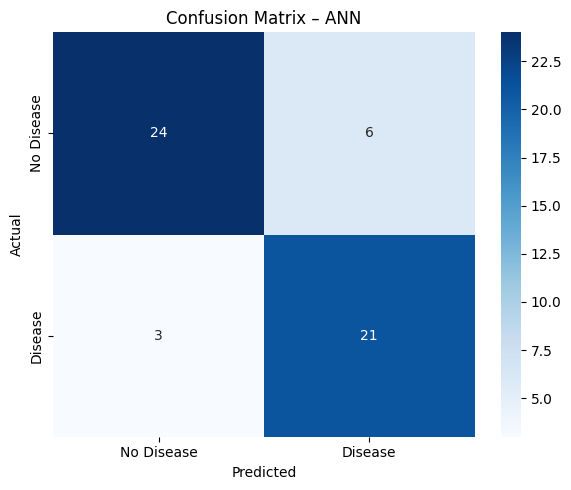

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix – ANN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

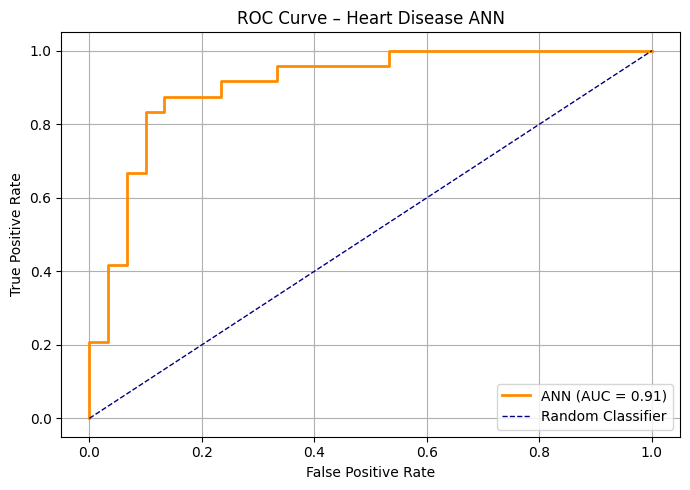

In [17]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ANN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Heart Disease ANN')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Predict on a Single New Patient

In [18]:
# Example patient (same feature order as training data)
# age, gender, chest_pain, rest_bps, cholestrol, fasting_blood_sugar,
# rest_ecg, thalach, exer_angina, old_peak, slope, ca, thalassemia

new_patient = np.array([[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]])
new_patient_sc = scaler.transform(new_patient)

probability = model.predict(new_patient_sc)[0][0]
prediction  = 'Heart Disease Detected' if probability >= 0.5 else 'No Heart Disease'

print(f'Prediction  : {prediction}')
print(f'Probability : {probability:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction  : No Heart Disease
Probability : 0.3914
